# 04 — Visualisation

Generate and export charts to outputs/figures/.

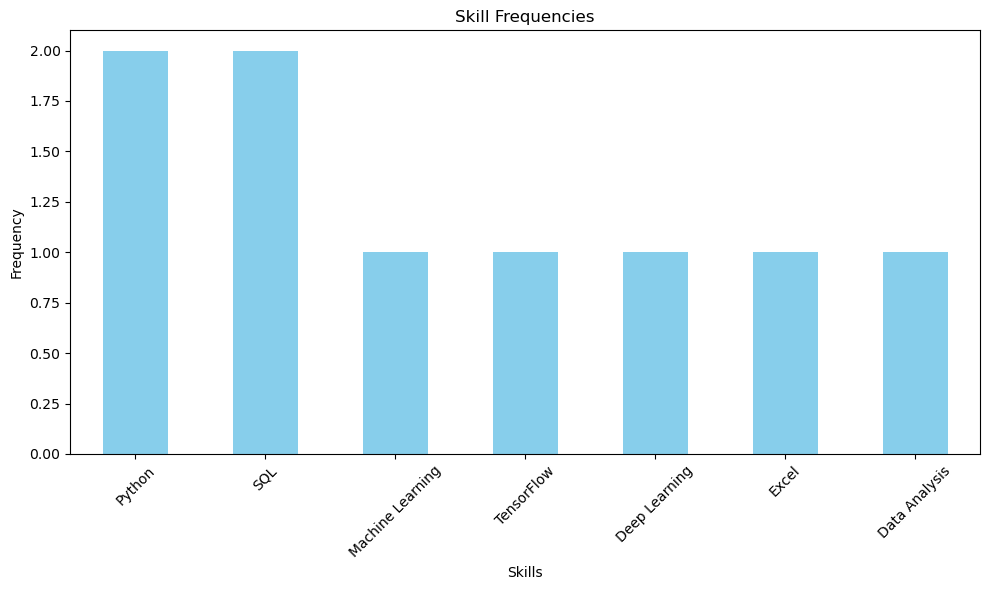

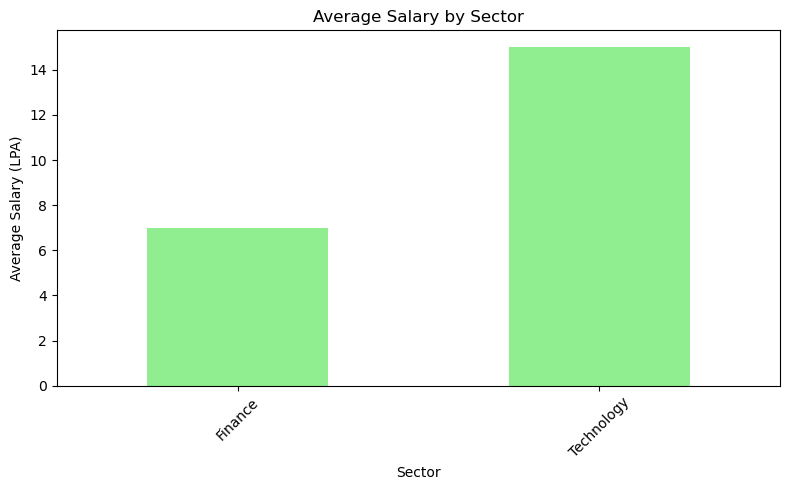

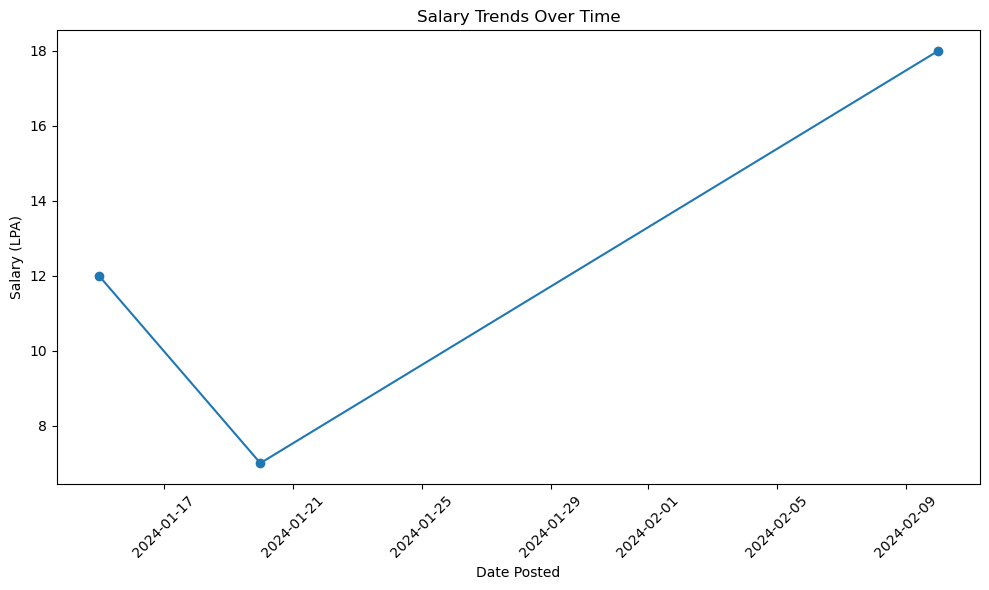

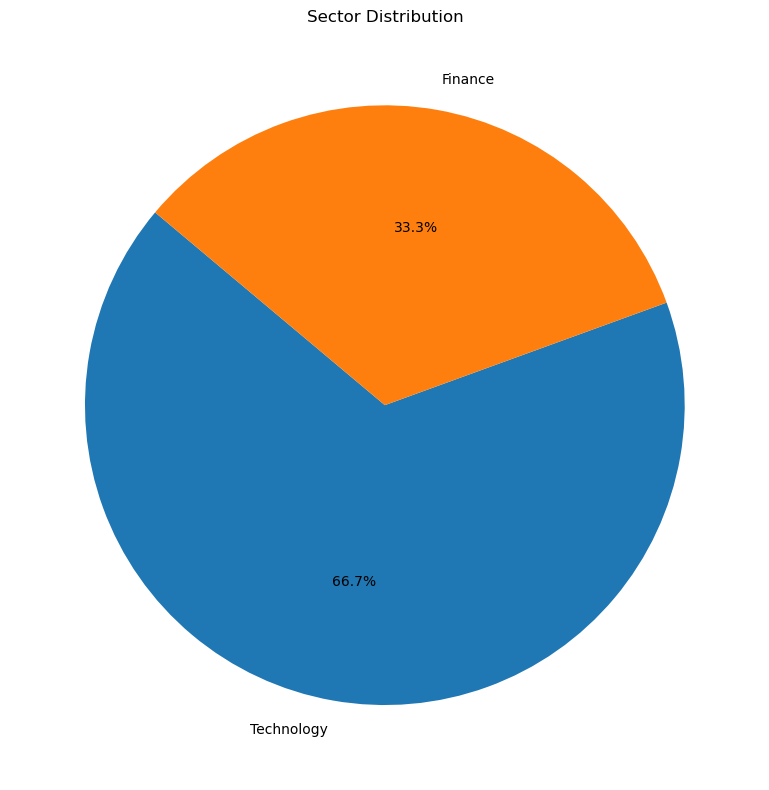

Visualizations generated and saved to outputs/figures/


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned data
df_clean = pd.read_csv('../data/processed/cleaned_job_postings.csv')
df_clean['skills_list'] = df_clean['skills_required'].str.split(',')
df_clean['date_posted'] = pd.to_datetime(df_clean['date_posted'])

# Skill frequencies bar chart
all_skills = df_clean['skills_list'].explode()
skill_freq = all_skills.value_counts()
plt.figure(figsize=(10, 6))
skill_freq.plot(kind='bar', color='skyblue')
plt.title('Skill Frequencies')
plt.xlabel('Skills')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/skill_frequencies.png')
plt.show()

# Average salary by sector
avg_salary_by_sector = df_clean.groupby('sector')['salary_lpa'].mean()
plt.figure(figsize=(8, 5))
avg_salary_by_sector.plot(kind='bar', color='lightgreen')
plt.title('Average Salary by Sector')
plt.xlabel('Sector')
plt.ylabel('Average Salary (LPA)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/avg_salary_by_sector.png')
plt.show()

# Salary trend over time (line plot)
df_sorted = df_clean.sort_values('date_posted')
plt.figure(figsize=(10, 6))
plt.plot(df_sorted['date_posted'], df_sorted['salary_lpa'], marker='o')
plt.title('Salary Trends Over Time')
plt.xlabel('Date Posted')
plt.ylabel('Salary (LPA)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/salary_trends.png')
plt.show()

# Sector distribution pie chart
sector_dist = df_clean['sector'].value_counts()
plt.figure(figsize=(8, 8))
sector_dist.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Sector Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../outputs/figures/sector_distribution.png')
plt.show()

print("Visualizations generated and saved to outputs/figures/")